# Assignment-2: Implementing and Analyzing Variational Autoencoder (VAE)

**Course:** CS772  
**Submission:** (1) this completed `.ipynb` notebook, and (2) a separate PDF containing all derivations and written answers. The PDF has to be uploaded on **Gradescope** and the notebook has to be uploaded as a **zip file** on the following **Dropbox** link: https://www.dropbox.com/request/br97unrk59kal356hnpf

## Background and Notation

We observe data $x \in \mathbb{R}^D$ and posit a latent variable model:

$$p_\theta(x, z) = p_\theta(x|z)\, p(z)$$

where $p(z) = \mathcal{N}(0, I)$ is a fixed standard normal prior and $p_\theta(x|z)$ is a learned decoder. We want to maximize $\log p_\theta(x)$, but the integral $\int p_\theta(x|z)\,p(z)\,dz$ is intractable.

The VAE (Kingma & Welling, 2013) introduces a learned approximate posterior $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x),\, \mathrm{diag}(\sigma^2_\phi(x)))$, whose parameters are output by an encoder network. Applying Jensen's inequality yields the **Evidence Lower BOund (ELBO)**:

$$\log p_\theta(x) \;\geq\; \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction term}} \;-\; \underbrace{D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right)}_{\text{Regularization term}} \;=:\; \mathcal{L}(\theta, \phi; x)$$

Training maximizes the ELBO jointly over $\theta$ and $\phi$.

> **Notation:** The encoder outputs two $d$-dimensional vectors: $\mu$ (mean) and $\log\sigma^2$ (log-variance `logvar`).

---
## Setup

In [ ]:
import torch, random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

SEED = hash("CS772") % (2**32 - 1)  # for reproducibility
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
Z_DIM      = 10
EPOCHS     = 10
LR         = 1e-3

transform     = transforms.ToTensor()   # pixels in [0, 1]
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f"Using device: {DEVICE}")

Using device: cpu


---
## Model Architecture

The encoder and decoder are defined as separate modules. The `VAE` class composes them and implements the reparameterization trick.

In [ ]:
class Encoder(nn.Module):
    """
    Maps a flat input x (784-d) to the parameters of q_φ(z|x):
    a mean vector μ and a log-variance vector log σ², each of shape (z_dim,).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, z_dim)
        self.fc_logvar = nn.Linear(256, z_dim)

    def forward(self, x):
        h = self.net(x.view(-1, 784))
        return self.fc_mu(h), self.fc_logvar(h)

In [ ]:
class Decoder(nn.Module):
    """
    Maps a latent vector z (z_dim-d) to a reconstructed image.
    Output is in [0, 1] via sigmoid — interpreted as the mean of p_θ(x|z).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),    # pixels in [0, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 28, 28)

In [ ]:
class VAE(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: draw z ~ q_φ(z|x) = N(μ, diag(σ²))
        in a differentiable way by sampling eps ~ N(0,I) and multiplying.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon_x    = self.decoder(z)
        return recon_x, mu, logvar, z

---
## Part 1

### Q1.1  Reconstruction Loss (10 pts)

Assume the decoder models $p_\theta(x|z) = \mathcal{N}(f_\theta(z), \sigma^2 I)$, where $f_\theta(z)$ is the decoder output and $\sigma^2$ is a fixed constant.

1. Show algebraically that maximizing $\log p_\theta(x|z)$ under this Gaussian assumption is equivalent to minimizing the Mean Squared Error (MSE) between $x$ and $f_\theta(z)$.*

2. In practice we implement a deterministic decoder. The network outputs only the mean $f_\theta(z)$ and the variance is ignored. Briefly explain what this implies about the quality of VAE-generated images.

3. An alternative is to model each pixel as an independent Bernoulli: $p_\theta(x|z) = \prod_i \text{Bern}(x_i;\, \hat{x}_i)$. What loss function does this correspond to? Why might this be more principled for MNIST than MSE?

### Q1.2  Closed-Form KL Divergence (10 pts)

Given $q_\phi(z|x) = \mathcal{N}(\mu, \mathrm{diag}(\sigma^2))$ and $p(z) = \mathcal{N}(0, I)$, derive the following closed-form expression starting only from the definition of KL divergence:

$$D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right) = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$


---
## Part 2  Implementation

### Q2.1  Reparameterization (5 pts)

Implement `reparameterize` in the `VAE` class above and explain why this trick is necessary. What goes wrong if you write `z = torch.distributions.Normal(mu, sigma).sample()` and try to backpropagate.

### Q2.2  Loss Function (10 pts)

Implement the VAE loss below. Use **MSE** for the reconstruction term and the **closed-form KL** from Q1.2.

> **Reduction:** use `.sum(dim=1).mean()` — sum over pixels and latent dimensions, then average over the batch.

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    """
    VAE ELBO loss (negated — we minimize this).

    Args:
        recon_x : (B, 784)        decoder output, pixel values in [0, 1]
        x       : (B, 1, 28, 28)  original images
        mu      : (B, z_dim)
        logvar  : (B, z_dim)      log σ²

    Returns:
        recon_l : scalar reconstruction term
        kl_l    : scalar KL term
    """
    B = x.size(0)
    # Reshape x to (B, 784) for MSE
    x_flat = x.view(B, -1)
    recon_x_flat = recon_x.view(B, -1)

    # Reconstruction loss: sum over pixels, average over batch
    recon_l = F.mse_loss(recon_x_flat, x_flat, reduction='none').sum(dim=1).mean()

    # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var)), sum over latent dim, average over batch
    kl_l = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    return recon_l, kl_l

### Q2.3  Training Loop (5 pts)

Implement the training loop below. Log total loss, reconstruction loss, and KL loss separately each epoch. After training, plot all three on a single figure.

In [ ]:
def train(model, optimizer, loss_fn, loader, epochs=EPOCHS, beta=1.0, L=None):
    model.train()
    history = {'loss': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0

        for batch_idx, (data, _) in enumerate(loader):
            data = data.to(DEVICE)
            optimizer.zero_grad()

            recon_batch, mu, logvar, z = model(data)

            if L is not None:
                recon_l, kl_l = loss_fn(recon_batch, data, mu, logvar, L)
            else:
                recon_l, kl_l = loss_fn(recon_batch, data, mu, logvar)

            # ELBO formulation with beta weighting
            loss = recon_l + beta * kl_l

            loss.backward()
            total_loss += loss.item() * data.size(0)
            total_recon += recon_l.item() * data.size(0)
            total_kl += kl_l.item() * data.size(0)

            optimizer.step()

        n = len(loader.dataset)
        avg_loss = total_loss / n
        avg_recon = total_recon / n
        avg_kl = total_kl / n

        history['loss'].append(avg_loss)
        history['recon'].append(avg_recon)
        history['kl'].append(avg_kl)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}")

    return history

Training standard VAE (beta=1)
Epoch 1/10 | Loss: 46.9966 | Recon: 43.6151 | KL: 3.3815
Epoch 2/10 | Loss: 34.3218 | Recon: 26.5322 | KL: 7.7896
Epoch 3/10 | Loss: 32.1915 | Recon: 23.5848 | KL: 8.6067
Epoch 4/10 | Loss: 31.2038 | Recon: 22.2448 | KL: 8.9590
Epoch 5/10 | Loss: 30.5517 | Recon: 21.3136 | KL: 9.2381
Epoch 6/10 | Loss: 30.0686 | Recon: 20.6515 | KL: 9.4171
Epoch 7/10 | Loss: 29.6633 | Recon: 20.0892 | KL: 9.5741
Epoch 8/10 | Loss: 29.3516 | Recon: 19.6586 | KL: 9.6930
Epoch 9/10 | Loss: 29.0838 | Recon: 19.2905 | KL: 9.7934
Epoch 10/10 | Loss: 28.8766 | Recon: 18.9927 | KL: 9.8840


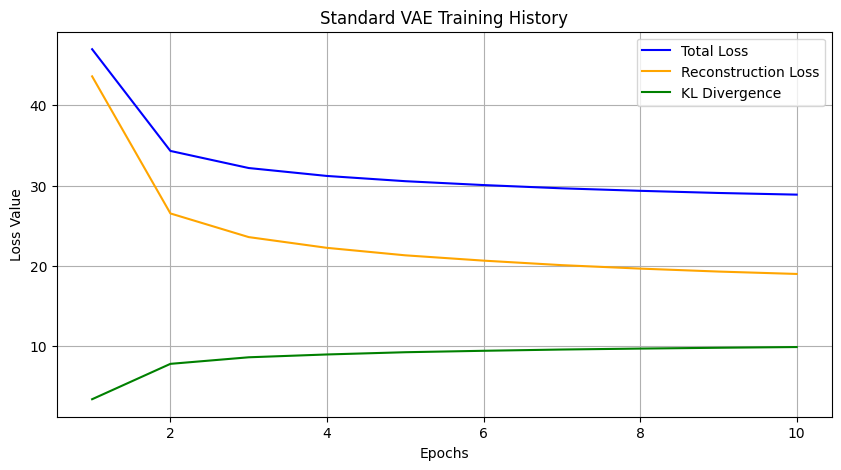

In [ ]:
# Train the standard model (β = 1)
model     = VAE().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

print("Training standard VAE (beta=1)")
history = train(model, optimizer, vae_loss, train_loader)

plt.figure(figsize=(10, 5))
epochs_range = range(1, EPOCHS + 1)
plt.plot(epochs_range, history['loss'], label='Total Loss', color='blue')
plt.plot(epochs_range, history['recon'], label='Reconstruction Loss', color='orange')
plt.plot(epochs_range, history['kl'], label='KL Divergence', color='green')
plt.title('Standard VAE Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()

### Q2.4  Monte Carlo KL Approximation (15 pts)

The KL term can be estimated without a closed form using Monte Carlo (MC) sampling:

$$D_{\mathrm{KL}}(q_\phi(z|x) \| p(z)) = \mathbb{E}_{q_\phi(z|x)}\!\left[\log q_\phi(z|x) - \log p(z)\right] \approx \frac{1}{L}\sum_{\ell=1}^{L}\left[\log q_\phi(z^{(\ell)}|x) - \log p(z^{(\ell)})\right]$$

where each $z^{(\ell)} \sim q_\phi(z|x)$ is drawn using the reparameterization trick.

1. Implement `vae_loss_mc` below. Draw $L$ samples *inside* the loss function. Use `torch.distributions.Normal` for the log-probability evaluations.
2. Train three fresh models using `vae_loss_mc` with $L \in \{1, 10, 100\}$. Plot the KL loss curves for all three alongside your closed-form baseline.
3.Describe qualitatively what you observe in the $L=1$ KL curve compared to $L=100$. Why is high variance in this gradient estimate specifically harmful during early training? Why would you prefer the closed form when it is available, even if $L$ is large?

In [ ]:
def vae_loss_mc(recon_x, x, mu, logvar, L=1):
    """
    VAE loss with MC-estimated KL using L samples.

    Args:
        recon_x : (B, 784)
        x       : (B, 1, 28, 28)
        mu      : (B, z_dim)
        logvar  : (B, z_dim)
        L       : number of MC samples for the KL estimate

    Returns: (recon_l, kl_l)
    """
    B, z_dim = mu.shape
    x_flat = x.view(B, -1)
    recon_x_flat = recon_x.view(B, -1)

    # Recon term (MSE)
    recon_l = F.mse_loss(recon_x_flat, x_flat, reduction='none').sum(dim=1).mean()

    # 1. Reparameterization draw L samples
    std = torch.exp(0.5 * logvar)
    # Shape: (L, B, z_dim)
    eps = torch.randn(L, B, z_dim, device=mu.device)
    z_samples = mu.unsqueeze(0) + eps * std.unsqueeze(0)

    # 2. Evaluate log q_phi(z|x) and log p(z)
    q_dist = torch.distributions.Normal(mu, std)
    p_dist = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))

    # log q_phi(z|x) -> sum over latent dim
    log_q = q_dist.log_prob(z_samples).sum(dim=-1)  # (L, B)
    # log p(z) -> sum over latent dim
    log_p = p_dist.log_prob(z_samples).sum(dim=-1)  # (L, B)

    # 3. KL approximation per item in batch: average over L
    kl_l_mc_batch = (log_q - log_p).mean(dim=0)  # (B,)
    kl_l = kl_l_mc_batch.mean()  # average over batch

    return recon_l, kl_l


Training with MC KL Approximation L=1
Epoch 1/10 | Loss: 47.4948 | Recon: 44.3925 | KL: 3.1023
Epoch 2/10 | Loss: 34.8458 | Recon: 27.5379 | KL: 7.3078
Epoch 3/10 | Loss: 32.2844 | Recon: 23.8434 | KL: 8.4411
Epoch 4/10 | Loss: 31.1470 | Recon: 22.2422 | KL: 8.9047
Epoch 5/10 | Loss: 30.5103 | Recon: 21.3264 | KL: 9.1839
Epoch 6/10 | Loss: 30.0386 | Recon: 20.6539 | KL: 9.3847
Epoch 7/10 | Loss: 29.6445 | Recon: 20.1074 | KL: 9.5371
Epoch 8/10 | Loss: 29.3458 | Recon: 19.6789 | KL: 9.6668
Epoch 9/10 | Loss: 29.0879 | Recon: 19.3159 | KL: 9.7720
Epoch 10/10 | Loss: 28.8620 | Recon: 18.9968 | KL: 9.8652

Training with MC KL Approximation L=10
Epoch 1/10 | Loss: 47.2750 | Recon: 44.0014 | KL: 3.2736
Epoch 2/10 | Loss: 34.6800 | Recon: 27.3462 | KL: 7.3338
Epoch 3/10 | Loss: 32.5861 | Recon: 24.5295 | KL: 8.0566
Epoch 4/10 | Loss: 31.5841 | Recon: 23.1723 | KL: 8.4118
Epoch 5/10 | Loss: 30.8877 | Recon: 22.2011 | KL: 8.6866
Epoch 6/10 | Loss: 30.3159 | Recon: 21.3423 | KL: 8.9736
Epoch 7/

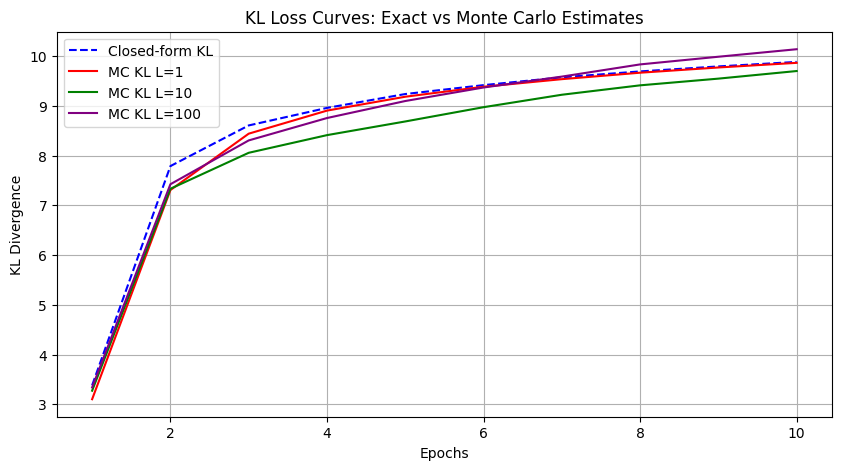

In [ ]:
# Train with L = 1, 10, 100 and plot KL curves
L_vals = [1, 10, 100]
mc_histories = {}

for L in L_vals:
    print(f"\nTraining with MC KL Approximation L={L}")
    mc_model = VAE().to(DEVICE)
    mc_opt = optim.Adam(mc_model.parameters(), lr=LR)

    # Train tracking history
    h = train(mc_model, mc_opt, vae_loss_mc, train_loader, epochs=EPOCHS, beta=1.0, L=L)
    mc_histories[L] = h

# Plotting MC KL alongside closed form
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history['kl'], label='Closed-form KL', color='blue', linestyle='--')
for L, color in zip(L_vals, ['red', 'green', 'purple']):
    plt.plot(epochs_range, mc_histories[L]['kl'], label=f'MC KL L={L}', color=color)

plt.title('KL Loss Curves: Exact vs Monte Carlo Estimates')
plt.xlabel('Epochs')
plt.ylabel('KL Divergence')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 3  $\beta$-VAE and Posterior Collapse

We introduce a scalar $\beta \geq 0$ weighting the KL term:

$$\mathcal{L}_\beta = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - \beta \cdot D_{\mathrm{KL}}(q_\phi(z|x) \| p(z))$$

The standard VAE is $\beta = 1$. Higgins et al. (2017) showed $\beta > 1$ encourages disentangled representations at the cost of reconstruction quality.

### Q3.1  Training (5 pts)

Modify your training loop to accept `beta`. Train three models with $\beta \in \{0.1, 1.0, 10.0\}$ for `EPOCHS` epochs. Show plots of the reconstruction and KL loss curves for all three settings.


Training Beta-VAE with beta=0.1
Epoch 1/10 | Loss: 37.8536 | Recon: 36.3782 | KL: 14.7546
Epoch 2/10 | Loss: 19.5227 | Recon: 17.0612 | KL: 24.6148
Epoch 3/10 | Loss: 16.9335 | Recon: 14.4156 | KL: 25.1790
Epoch 4/10 | Loss: 15.7295 | Recon: 13.1915 | KL: 25.3799
Epoch 5/10 | Loss: 14.9762 | Recon: 12.4204 | KL: 25.5586
Epoch 6/10 | Loss: 14.4517 | Recon: 11.8837 | KL: 25.6797
Epoch 7/10 | Loss: 14.0383 | Recon: 11.4613 | KL: 25.7696
Epoch 8/10 | Loss: 13.6931 | Recon: 11.1056 | KL: 25.8751
Epoch 9/10 | Loss: 13.4108 | Recon: 10.8175 | KL: 25.9327
Epoch 10/10 | Loss: 13.1607 | Recon: 10.5595 | KL: 26.0116

Training Beta-VAE with beta=1.0
Epoch 1/10 | Loss: 47.3925 | Recon: 43.9668 | KL: 3.4257
Epoch 2/10 | Loss: 34.5295 | Recon: 26.7534 | KL: 7.7761
Epoch 3/10 | Loss: 32.1760 | Recon: 23.5011 | KL: 8.6749
Epoch 4/10 | Loss: 31.0471 | Recon: 21.8699 | KL: 9.1771
Epoch 5/10 | Loss: 30.3216 | Recon: 20.7428 | KL: 9.5788
Epoch 6/10 | Loss: 29.8263 | Recon: 20.0280 | KL: 9.7983
Epoch 7/10 

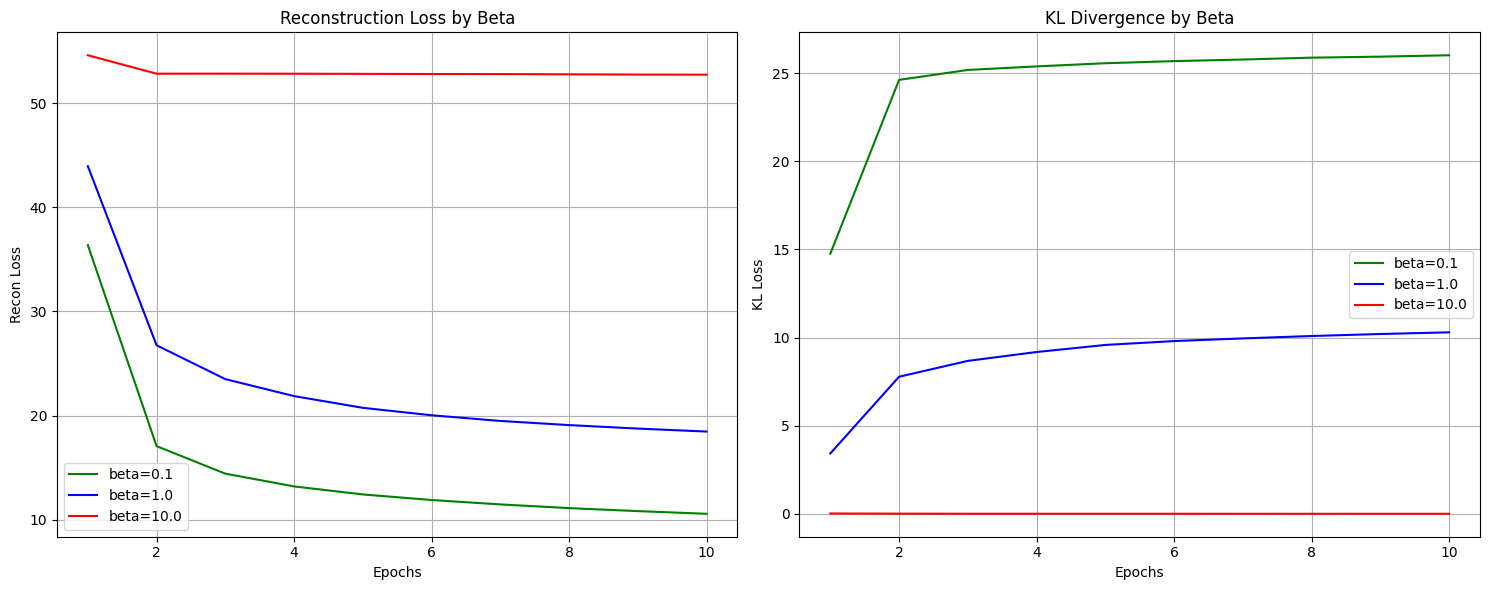

In [ ]:
betas    = [0.1, 1.0, 10.0]
histories = {}
beta_models = {}

for beta in betas:
    print(f"\nTraining Beta-VAE with beta={beta}")
    b_model = VAE().to(DEVICE)
    b_opt = optim.Adam(b_model.parameters(), lr=LR)

    # Train tracking history
    hist = train(b_model, b_opt, vae_loss, train_loader, epochs=EPOCHS, beta=beta)
    histories[beta] = hist
    beta_models[beta] = b_model

# Plot reconstruction and KL loss curves for all three β values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = ['green', 'blue', 'red']
for beat, color in zip(betas, colors):
    h = histories[beat]
    ax1.plot(epochs_range, h['recon'], label=f'beta={beat}', color=color)
    ax2.plot(epochs_range, h['kl'], label=f'beta={beat}', color=color)

ax1.set_title("Reconstruction Loss by Beta")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Recon Loss")
ax1.legend()
ax1.grid(True)

ax2.set_title("KL Divergence by Beta")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("KL Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Q3.2 — Posterior Collapse Analysis (15 pts)

Posterior collapse occurs when the encoder ignores the input and maps everything to the prior: $q_\phi(z|x) \approx p(z)$ regardless of $x$.

1. For each trained model, use `compute_active_dims` below to compute the per-dimension variance of the encoder means across the test set.
2. For each $\beta$, show a plot of the per-dimension variance across all 20 latent dimensions.
3. What happens to the latent dimensions under $\beta = 10.0$? Provide a explanation why does a large $\beta$ incentivize the encoder to ignore the input? Why does the decoder then receive no useful signal from those dimensions?

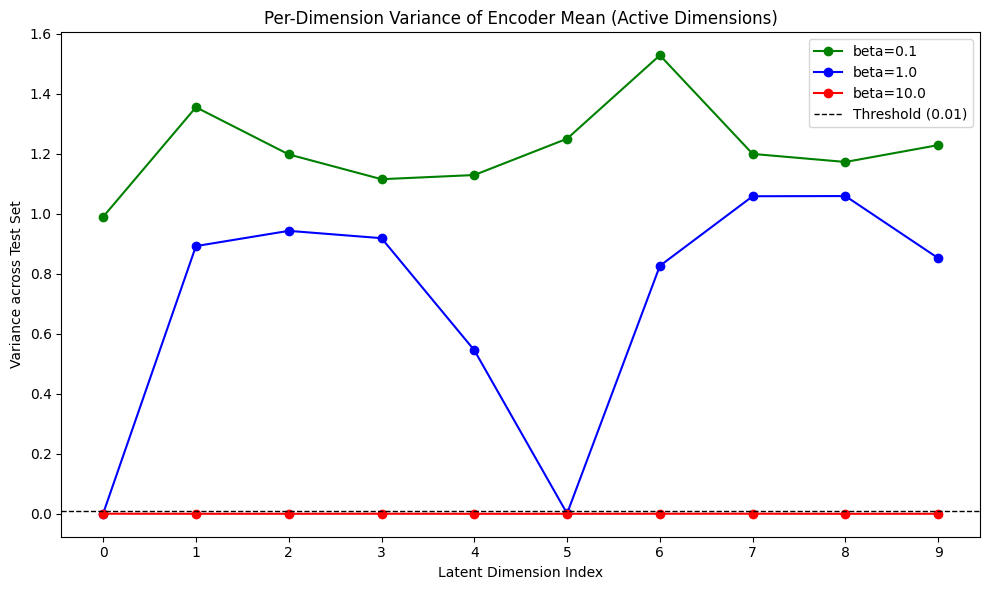

In [ ]:
def compute_active_dims(model, loader, device=DEVICE):
    """
    Returns: (z_dim,) tensor — per-dimension variance of encoder means
    across the test set.
    """
    model.eval()
    all_mu = []
    with torch.no_grad():
        for x, _ in loader:
            mu, _ = model.encoder(x.to(device))
            all_mu.append(mu.cpu())
    all_mu = torch.cat(all_mu, dim=0)   # (N_test, z_dim)
    return all_mu.var(dim=0)            # (z_dim,)

# Compute and plot active dimensions for each β
plt.figure(figsize=(10, 6))
indices = np.arange(Z_DIM)

for i, (beta, color) in enumerate(zip(betas, colors)):
    vars_dim = compute_active_dims(beta_models[beta], test_loader)
    plt.plot(indices, vars_dim.numpy(), marker='o', linestyle='-', color=color,
            label=f'beta={beta}')

plt.title('Per-Dimension Variance of Encoder Mean (Active Dimensions)')
plt.xlabel('Latent Dimension Index')
plt.ylabel('Variance across Test Set')
plt.xticks(indices, [str(i) for i in range(Z_DIM)])
plt.axhline(0.01, color='black', linestyle='--', linewidth=1, label='Threshold (0.01)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 4  Geometry of the Latent Space

### Q4.1  Linear Interpolation (15 pts)

A well-trained VAE should produce a smooth, connected latent space: nearby points in $\mathbb{R}^d$ should decode to semantically similar images.

Using your $\beta = 1.0$ model:

1. Pick one test image of digit "2" and one of digit "7". Pass each through the encoder and record the **mean vectors** $\mu_A$ and $\mu_B$ (use the mean, not a sample).
2. Generate 10 interpolated latent vectors: $z_t = (1-t)\,\mu_A + t\,\mu_B,\quad t \in \{0.0,\,0.1,\,\ldots,\,1.0\}$
3. Decode each $z_t$ and display the resulting images.
4. Do you observe a smooth semantic transition? Describe what the intermediate images look like. Why does the KL regularization term play a direct role in enabling this, while a standard Autoencoder (no KL term) would not guarantee it?

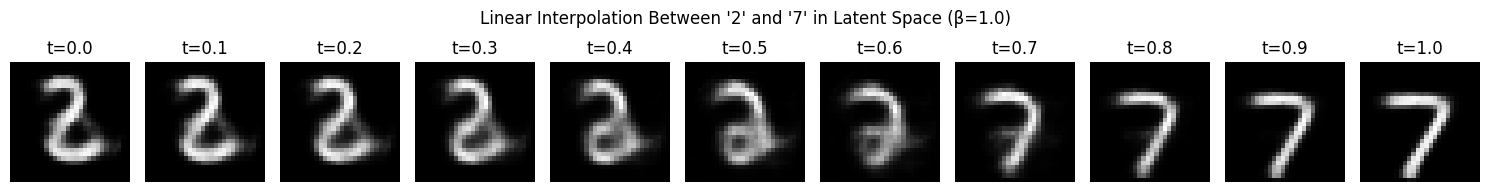

In [ ]:
# Find a digit '2' and a digit '7' in the test dataset
img_2 = None
img_7 = None

for x, y in test_dataset:
    if img_2 is None and y == 2:
        img_2 = x.to(DEVICE)
    if img_7 is None and y == 7:
        img_7 = x.to(DEVICE)
    if img_2 is not None and img_7 is not None:
        break

# Use the beta=1.0 model
model_1 = beta_models[1.0]
model_1.eval()

# Encode to get means (ignoring log_var and sample since we just want the mean trajectory)
with torch.no_grad():
    mu_A, _ = model_1.encoder(img_2.unsqueeze(0))  # shape: (1, z_dim)
    mu_B, _ = model_1.encoder(img_7.unsqueeze(0))

# Interpolate and Decode
n_steps = 11
lambdas = np.linspace(0.0, 1.0, n_steps)

fig, axes = plt.subplots(1, n_steps, figsize=(15, 2))
with torch.no_grad():
    for i, t in enumerate(lambdas):
        z_t = (1 - t) * mu_A + t * mu_B

        recon_t = model_1.decoder(z_t).cpu().view(28, 28)

        axes[i].imshow(recon_t, cmap='gray')
        axes[i].set_title(f't={t:.1f}')
        axes[i].axis('off')

plt.suptitle("Linear Interpolation Between '2' and '7' in Latent Space (β=1.0)")
plt.tight_layout()
plt.show()

### Q4.2 — 2-D Latent Space Visualization *(Bonus, 10 pts)*

Retrain a VAE with `Z_DIM = 2`. Encode the full test set, collect all $\mu$ vectors, and plot them colored by digit class. Describe the structure: are digit classes separated? Do visually similar digits cluster near each other?

Training 2D Latent Space Model...
Epoch 1/20 | Loss: 49.5100 | Recon: 47.6752 | KL: 1.8348
Epoch 2/20 | Loss: 41.0416 | Recon: 37.4112 | KL: 3.6304
Epoch 3/20 | Loss: 39.1759 | Recon: 35.0784 | KL: 4.0975
Epoch 4/20 | Loss: 38.2370 | Recon: 33.8953 | KL: 4.3417
Epoch 5/20 | Loss: 37.5693 | Recon: 33.0544 | KL: 4.5150
Epoch 6/20 | Loss: 37.0502 | Recon: 32.3834 | KL: 4.6668
Epoch 7/20 | Loss: 36.5580 | Recon: 31.7624 | KL: 4.7957
Epoch 8/20 | Loss: 36.1745 | Recon: 31.2712 | KL: 4.9033
Epoch 9/20 | Loss: 35.8924 | Recon: 30.9108 | KL: 4.9816
Epoch 10/20 | Loss: 35.6363 | Recon: 30.5727 | KL: 5.0636
Epoch 11/20 | Loss: 35.4042 | Recon: 30.2955 | KL: 5.1087
Epoch 12/20 | Loss: 35.2356 | Recon: 30.0672 | KL: 5.1685
Epoch 13/20 | Loss: 35.0034 | Recon: 29.8176 | KL: 5.1858
Epoch 14/20 | Loss: 34.8856 | Recon: 29.6564 | KL: 5.2292
Epoch 15/20 | Loss: 34.7501 | Recon: 29.4854 | KL: 5.2647
Epoch 16/20 | Loss: 34.6313 | Recon: 29.3488 | KL: 5.2825
Epoch 17/20 | Loss: 34.5143 | Recon: 29.1982 | 

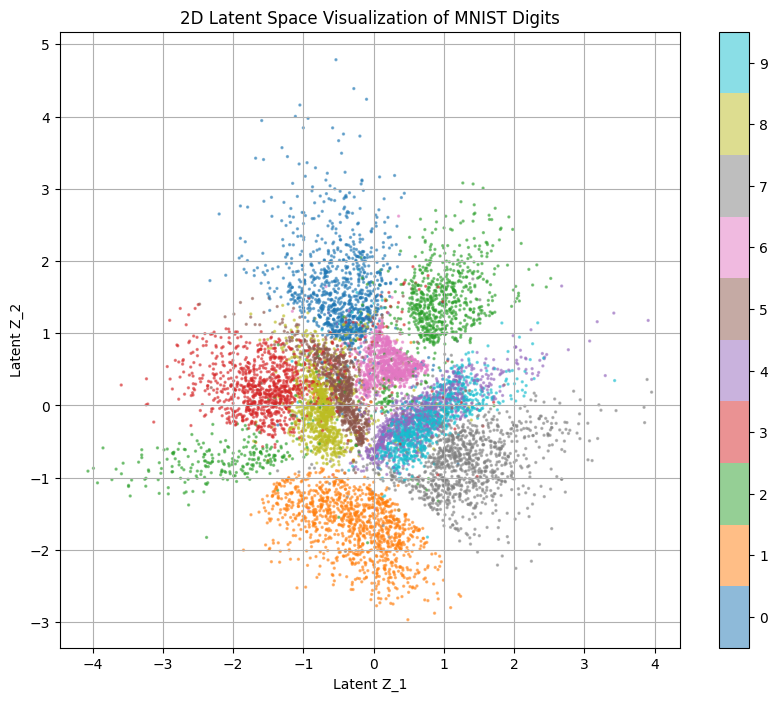

In [ ]:
print("Training 2D Latent Space Model...")
Z_DIM_2D = 2
model_2d = VAE(z_dim=Z_DIM_2D).to(DEVICE)
opt_2d = optim.Adam(model_2d.parameters(), lr=LR)

# Using standard vae_loss (beta=1)
train(model_2d, opt_2d, vae_loss, train_loader, epochs=2*EPOCHS, beta=1.0)

# Evaluate and plot
model_2d.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        mu_batch, _ = model_2d.encoder(x.to(DEVICE))
        all_mu.append(mu_batch.cpu())
        all_labels.append(y.cpu())

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=2)
plt.colorbar(scatter, boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title("2D Latent Space Visualization of MNIST Digits")
plt.xlabel("Latent Z_1")
plt.ylabel("Latent Z_2")
plt.grid(True)
plt.show()

---
## References

- Kingma, D. P. & Welling, M. (2013). *Auto-Encoding Variational Bayes.* ICLR 2014. arXiv:1312.6114  
- Higgins, I. et al. (2017). *β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework.* ICLR 2017.  
- Lucas, J. et al. (2019). *Don't Blame the ELBO! A Linear VAE Perspective on Posterior Collapse.* NeurIPS 2019.